# Summarization Model Evaluation

This notebook evaluates different summarization models for financial news articles:
- Zero-shot baseline model (using pretrained BART without examples)
- Few-shot baseline model (using pretrained BART with financial examples)
- Fine-tuned model (BART fine-tuned on financial news)

We'll evaluate these models beyond standard metrics like ROUGE or BLEU by:
- Assessing factual accuracy of summaries
- Identifying hallucinations
- Comparing the improvement from fine-tuning

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Optional
from datetime import datetime
import torch
from tqdm.notebook import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline
from rouge_score import rouge_scorer
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter

# Add the parent directory to the path so we can import project modules
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_dir = os.path.dirname(notebook_dir)
sys.path.append(project_dir)

# Import project modules
from scripts.vector_db_manager import VectorDatabaseManager

# Download NLTK resources if needed
nltk.download('punkt')
nltk.download('stopwords')

/Users/giannisalexandrou/.local/share/virtualenvs/trading-agent-Iwjhydeb/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
W0518 21:02:30.081000 52694 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/giannisalexandrou/.local/share/virtualenvs/trading-agent-Iwjhydeb/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/giannisalexandrou/.local/share/virtualenvs/trading-agent-Iwjhydeb/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use 

True

## Configuration

Set up the paths and parameters for the evaluation.

In [2]:
# Path configurations
DB_PATH = os.path.join(project_dir, "data", "chroma_db")
COLLECTION_NAME = "financial_articles"
FINETUNED_MODEL_DIR = os.path.join(project_dir, "models", "bart-finetuned-2")
BASELINE_MODEL = "facebook/bart-large-cnn"  # Default baseline model for summarization

# Number of articles to evaluate
NUM_ARTICLES = 10

# Summarization parameters
MAX_LENGTH = 150
MIN_LENGTH = 40

# Check if CUDA is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Retrieving Test Articles from Vector Database

Connect to the vector database and retrieve a sample of financial news articles for evaluation.

In [3]:
def get_test_articles(db_manager, num_articles=10, filter_stock=None):
    """
    Get a sample of articles with summaries from the vector database.
    
    Args:
        db_manager: VectorDatabaseManager instance
        num_articles: Number of articles to retrieve
        filter_stock: Optional stock symbol to filter by
        
    Returns:
        List of articles with their metadata and summaries
    """
    # Query string - we'll retrieve diverse samples related to finance
    query_string = f"financial news about {filter_stock}" if filter_stock else "diverse financial news articles"
    
    # Query the database for articles
    fetch_limit = num_articles * 3  # Request more to ensure we get enough with summaries
    results = db_manager.query_database(
        query=query_string,
        n_results=fetch_limit,
        include_summary=True
    )
    
    # Process results into a usable format
    articles = []
    seen_articles = set()  # To avoid duplicates
    
    if results and 'documents' in results and results['documents']:
        # Handle nested lists
        documents = results['documents']
        if documents and isinstance(documents[0], list):
            documents = documents[0]
            
        metadatas = results['metadatas']
        if metadatas and isinstance(metadatas[0], list):
            metadatas = metadatas[0]
        
        # Process each article
        for i, doc in enumerate(documents):
            if len(articles) >= num_articles:  # Stop once we have enough
                break
                
            metadata = metadatas[i] if i < len(metadatas) else {}
            
            # Skip if no summary is available or we've seen this article
            article_id = metadata.get('article_id', None)
            summary = metadata.get('summary', '')
            if not summary or (article_id and article_id in seen_articles):
                continue
                
            # Add article to the list if it has a summary
            if article_id:
                seen_articles.add(article_id)
                
            article = {
                'text': doc,
                'title': metadata.get('title', 'No Title Available'),
                'original_summary': summary,
                'source': metadata.get('source', 'Unknown Source'),
                'pubDate': metadata.get('pubDate', ''),
                'stock_symbol': metadata.get('stock_symbol', ''),
                'article_id': article_id
            }
            articles.append(article)
    
    # Check if we have enough articles with summaries
    if len(articles) < num_articles:
        print(f"Warning: Could only find {len(articles)} articles with summaries")
    else:
        print(f"Retrieved {len(articles)} articles with summaries")
        
    return articles

In [4]:
# Initialize vector database manager
db_manager = VectorDatabaseManager(
    db_path=DB_PATH,
    collection_name=COLLECTION_NAME
)

# Optional: Get articles for a specific stock (change to None for mixed stocks)
stock_filter = "AAPL"

# Get test articles
test_articles = get_test_articles(
    db_manager=db_manager,
    num_articles=NUM_ARTICLES,
    filter_stock=stock_filter
)

# Display sample information
if test_articles:
    sample = test_articles[0]
    print(f"Sample article: {sample['title']}")
    print(f"Source: {sample['source']}")
    print(f"Stock: {sample['stock_symbol']}")
    print(f"\nOriginal summary: {sample['original_summary']}")
    print(f"\nText preview: {sample['text'][:300]}...")

/Users/giannisalexandrou/.local/share/virtualenvs/trading-agent-Iwjhydeb/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Initializing ChromaDB with persistence directory: /Users/giannisalexandrou/Documents/Personal Projects/Trading-Agent/trading-agent/data/chroma_db
Loaded existing collection 'financial_articles'
Collection 'financial_articles' contains 400 documents
Found 30 results. Showing top 3:

Result #1 (Similarity: 0.2473)
Title: Apple Inc. (NASDAQ:AAPL) Shares Sold by Townsend Asset Management Corp NC ADV
Source: Defenseworld Net
Date: 2025-05-16 07:35:05
Chunk: 1 of 2
Link: https://www.defenseworld.net/2025/05/16/apple-inc-nasdaqaapl-shares-sold-by-townsend-asset-management-corp-nc-adv.html
Creator: Defense World Staff
Summary: Townsend Asset Management Corp NC ADV lowered its holdings in shares of Apple Inc. (NASDAQ:AAPL – Free Report) by 13.0% in the fourth quarter, according to its most recent 13F filing with the SEC.
Apple comprises about 3.4% of Townsend Asset Management Corp NC ADV’s portfolio, making the stock its 7th biggest holding.
Townsend Asset Management Corp NC ADV’s holdings in A

## Implementing Summarization Models

We'll implement three different approaches to summarization:
1. Zero-shot: Using the pretrained model directly without examples
2. Few-shot: Using the pretrained model with financial examples
3. Fine-tuned: Using a domain-adapted model fine-tuned on financial data

In [12]:
def generate_zero_shot_summary(model_path, article_text):
    """
    Generate a zero-shot summary using the baseline model.
    
    Args:
        model_path: Path to the model
        article_text: Text to summarize
        
    Returns:
        Generated summary
    """
    # Truncate if too long
    max_text_length = 4000
    if len(article_text) > max_text_length:
        article_text = article_text[:max_text_length]
        print(f"Article truncated to {max_text_length} characters")
    
    # Initialize the summarization pipeline
    summarizer = pipeline(
        "summarization", 
        model=model_path,
        device=0 if torch.cuda.is_available() else -1  # Use GPU if available
    )
    
    # Generate summary
    summary_output = summarizer(
        article_text,
        max_length=MAX_LENGTH,
        min_length=MIN_LENGTH,
        do_sample=False
    )
    
    return summary_output[0]['summary_text']

def generate_few_shot_summary(model_path, article_text):
    """
    Generate a few-shot summary using examples of financial summaries.
    
    Args:
        model_path: Path to the model
        article_text: Text to summarize
        
    Returns:
        Generated summary
    """
    # Truncate if too long
    max_text_length = 4000
    if len(article_text) > max_text_length:
        article_text = article_text[:max_text_length]
        print(f"Article truncated to {max_text_length} characters")
    
    # Few-shot prompt with examples
    few_shot_prompt = """
    Here are some examples of good financial news summaries:
    
    Original: Apple Inc. reported record-breaking quarterly revenue of $91.8 billion, an increase of 9% from the same quarter a year ago. The company's services and wearables divisions showed strong growth, offsetting a slight decline in iPhone sales. CEO Tim Cook attributed the success to high customer satisfaction and loyalty.
    Summary: Apple reported record quarterly revenue of $91.8B, up 9% year-over-year, with strong growth in services and wearables compensating for lower iPhone sales.
    
    Original: Tesla's Q4 earnings beat Wall Street expectations with revenue reaching $24.3 billion. The electric vehicle maker delivered a record 405,278 vehicles in the quarter despite production challenges and increasing competition. The company announced plans to expand its manufacturing capacity and introduce new models in the coming year.
    Summary: Tesla exceeded Q4 expectations with $24.3B revenue and record 405,278 vehicle deliveries, while announcing manufacturing expansion and new model plans.
    
    Now summarize this financial news article:
    {article}
    """
    
    # Format the few-shot prompt with the article text
    few_shot_input = few_shot_prompt.format(article=article_text)
    
    # Truncate if too long after adding examples
    if len(few_shot_input) > max_text_length:
        print("Few-shot prompt too long, truncating...")
        few_shot_input = few_shot_input[-max_text_length:]
    
    # Initialize the summarization pipeline
    summarizer = pipeline(
        "summarization", 
        model=model_path,
        device=0 if torch.cuda.is_available() else -1  # Use GPU if available
    )
    
    # Generate summary
    summary_output = summarizer(
        few_shot_input,
        max_length=MAX_LENGTH,
        min_length=MIN_LENGTH,
        do_sample=False
    )
    
    return summary_output[0]['summary_text']

def generate_finetuned_summary(model_path, article_text):
    """
    Generate a summary using the fine-tuned model.
    
    Args:
        model_path: Path to the fine-tuned model
        article_text: Text to summarize
        
    Returns:
        Generated summary
    """
    # Truncate if too long
    max_text_length = 4000
    if len(article_text) > max_text_length:
        article_text = article_text[:max_text_length]
        print(f"Article truncated to {max_text_length} characters")
    
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path,early_stopping=True).to(device)
    
    # Tokenize the text
    inputs = tokenizer(article_text, return_tensors="pt", max_length=1024, 
                      truncation=True, padding="max_length").to(device)
    
    # Generate summary
    summary_ids = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=MAX_LENGTH,
        min_length=MIN_LENGTH,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
        no_repeat_ngram_size=3
    )
    
    # Decode the summary
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    return summary

## Generate Summaries

Now we'll generate summaries for each article using all three approaches.

In [9]:
def generate_all_summaries(articles):
    """
    Generate summaries for each article using all three approaches.
    
    Args:
        articles: List of article dictionaries
        
    Returns:
        List of articles with added summaries
    """
    for i, article in enumerate(tqdm(articles, desc="Generating summaries")):
        try:
            # Zero-shot summary
            article['zero_shot_summary'] = generate_zero_shot_summary(
                model_path=BASELINE_MODEL,
                article_text=article['text']
            )
            
            # Few-shot summary
            article['few_shot_summary'] = generate_few_shot_summary(
                model_path=BASELINE_MODEL,
                article_text=article['text']
            )
            
            # Fine-tuned summary
            article['finetuned_summary'] = generate_finetuned_summary(
                model_path=FINETUNED_MODEL_DIR,
                article_text=article['text']
            )
            
        except Exception as e:
            print(f"Error generating summaries for article {i}: {str(e)}")
            # Set empty values if there's an error
            if 'zero_shot_summary' not in article:
                article['zero_shot_summary'] = ""
            if 'few_shot_summary' not in article:
                article['few_shot_summary'] = ""
            if 'finetuned_summary' not in article:
                article['finetuned_summary'] = ""
    
    return articles

In [13]:
# Generate summaries for all test articles
articles_with_summaries = generate_all_summaries(test_articles)

# Display a sample of results
if articles_with_summaries:
    sample = articles_with_summaries[0]
    print(f"Article: {sample['title']}\n")
    
    print(f"Original Summary:\n{sample['original_summary']}\n")
    print(f"Zero-shot Summary:\n{sample['zero_shot_summary']}\n")
    print(f"Few-shot Summary:\n{sample['few_shot_summary']}\n")
    print(f"Fine-tuned Summary:\n{sample['finetuned_summary']}\n")

Generating summaries:   0%|          | 0/10 [00:00<?, ?it/s]

Your max_length is set to 150, but your input_length is only 131. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=65)
/Users/giannisalexandrou/.local/share/virtualenvs/trading-agent-Iwjhydeb/lib/python3.12/site-packages/transformers/generation/utils.py:1473: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
Your max_length is set to 150, but your input_length is only 91. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_l

Article: Apple Inc. (NASDAQ:AAPL) Shares Sold by Townsend Asset Management Corp NC ADV

Original Summary:
Townsend Asset Management Corp NC ADV lowered its holdings in shares of Apple Inc. (NASDAQ:AAPL – Free Report) by 13.0% in the fourth quarter, according to its most recent 13F filing with the SEC.
Apple comprises about 3.4% of Townsend Asset Management Corp NC ADV’s portfolio, making the stock its 7th biggest holding.
Townsend Asset Management Corp NC ADV’s holdings in Apple were worth $9,197,000 at the end of the most recent quarter.
Apple Stock Down 0.4%AAPL stock opened at $211.45 on Friday.
In the last three months, insiders have sold 191,507 shares of company stock valued at $42,694,080.

Zero-shot Summary:
Townsend Asset Management Corp NC ADV lowered its holdings in shares of Apple Inc. (NASDAQ:AAPL) by 13.0% in the fourth quarter. Apple comprises about 3.4% of the company’s portfolio, making the stock its 7th biggest holding. The firm now owns $9,197,000.

Few-shot Summary:

## Standard Evaluation Metrics

First, we'll evaluate the summaries using standard metrics like ROUGE and BLEU.

In [14]:
def calculate_rouge_scores(reference, candidate):
    """
    Calculate ROUGE scores for a summary.
    
    Args:
        reference: Reference summary (ground truth)
        candidate: Generated summary to evaluate
        
    Returns:
        Dictionary of ROUGE scores
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference, candidate)
    
    # Extract the F1 scores
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure
    }

def calculate_bleu_score(reference, candidate):
    """
    Calculate BLEU score for a summary.
    
    Args:
        reference: Reference summary (ground truth)
        candidate: Generated summary to evaluate
        
    Returns:
        BLEU score
    """
    # Tokenize the sentences
    reference_tokens = [word_tokenize(reference.lower())]
    candidate_tokens = word_tokenize(candidate.lower())
    
    # Calculate BLEU score with smoothing
    smoothie = SmoothingFunction().method1
    return sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=smoothie)

In [15]:
def evaluate_summaries_with_standard_metrics(articles):
    """
    Evaluate all generated summaries using standard metrics.
    
    Args:
        articles: List of article dictionaries with summaries
        
    Returns:
        Dictionary of evaluation results
    """
    results = {
        'zero_shot': {'rouge1': [], 'rouge2': [], 'rougeL': [], 'bleu': []},
        'few_shot': {'rouge1': [], 'rouge2': [], 'rougeL': [], 'bleu': []},
        'finetuned': {'rouge1': [], 'rouge2': [], 'rougeL': [], 'bleu': []}
    }
    
    for article in articles:
        # Skip articles without original summary
        if not article['original_summary']:
            continue
            
        reference = article['original_summary']
        
        # Evaluate zero-shot summary
        if article['zero_shot_summary']:
            rouge_scores = calculate_rouge_scores(reference, article['zero_shot_summary'])
            results['zero_shot']['rouge1'].append(rouge_scores['rouge1'])
            results['zero_shot']['rouge2'].append(rouge_scores['rouge2'])
            results['zero_shot']['rougeL'].append(rouge_scores['rougeL'])
            results['zero_shot']['bleu'].append(calculate_bleu_score(reference, article['zero_shot_summary']))
        
        # Evaluate few-shot summary
        if article['few_shot_summary']:
            rouge_scores = calculate_rouge_scores(reference, article['few_shot_summary'])
            results['few_shot']['rouge1'].append(rouge_scores['rouge1'])
            results['few_shot']['rouge2'].append(rouge_scores['rouge2'])
            results['few_shot']['rougeL'].append(rouge_scores['rougeL'])
            results['few_shot']['bleu'].append(calculate_bleu_score(reference, article['few_shot_summary']))
        
        # Evaluate fine-tuned summary
        if article['finetuned_summary']:
            rouge_scores = calculate_rouge_scores(reference, article['finetuned_summary'])
            results['finetuned']['rouge1'].append(rouge_scores['rouge1'])
            results['finetuned']['rouge2'].append(rouge_scores['rouge2'])
            results['finetuned']['rougeL'].append(rouge_scores['rougeL'])
            results['finetuned']['bleu'].append(calculate_bleu_score(reference, article['finetuned_summary']))
    
    return results

In [16]:
# Evaluate summaries using standard metrics
standard_metrics_results = evaluate_summaries_with_standard_metrics(articles_with_summaries)

# Calculate average scores
avg_results = {}
for model, metrics in standard_metrics_results.items():
    avg_results[model] = {}
    for metric, values in metrics.items():
        if values:  # Check if we have any scores
            avg_results[model][metric] = sum(values) / len(values)
        else:
            avg_results[model][metric] = 0

# Create a DataFrame for easy visualization
results_df = pd.DataFrame({
    'Model': ['Zero-shot', 'Few-shot', 'Fine-tuned'],
    'ROUGE-1': [
        avg_results['zero_shot']['rouge1'],
        avg_results['few_shot']['rouge1'],
        avg_results['finetuned']['rouge1']
    ],
    'ROUGE-2': [
        avg_results['zero_shot']['rouge2'],
        avg_results['few_shot']['rouge2'],
        avg_results['finetuned']['rouge2']
    ],
    'ROUGE-L': [
        avg_results['zero_shot']['rougeL'],
        avg_results['few_shot']['rougeL'],
        avg_results['finetuned']['rougeL']
    ],
    'BLEU': [
        avg_results['zero_shot']['bleu'],
        avg_results['few_shot']['bleu'],
        avg_results['finetuned']['bleu']
    ]
})

# Display results table
results_df

,Model,ROUGE-1,ROUGE-2,ROUGE-L,BLEU
0,Zero-shot,0.506028,0.473264,0.410378,0.158833
1,Few-shot,0.207014,0.102661,0.165334,0.036843
2,Fine-tuned,0.614291,0.562703,0.468182,0.377904


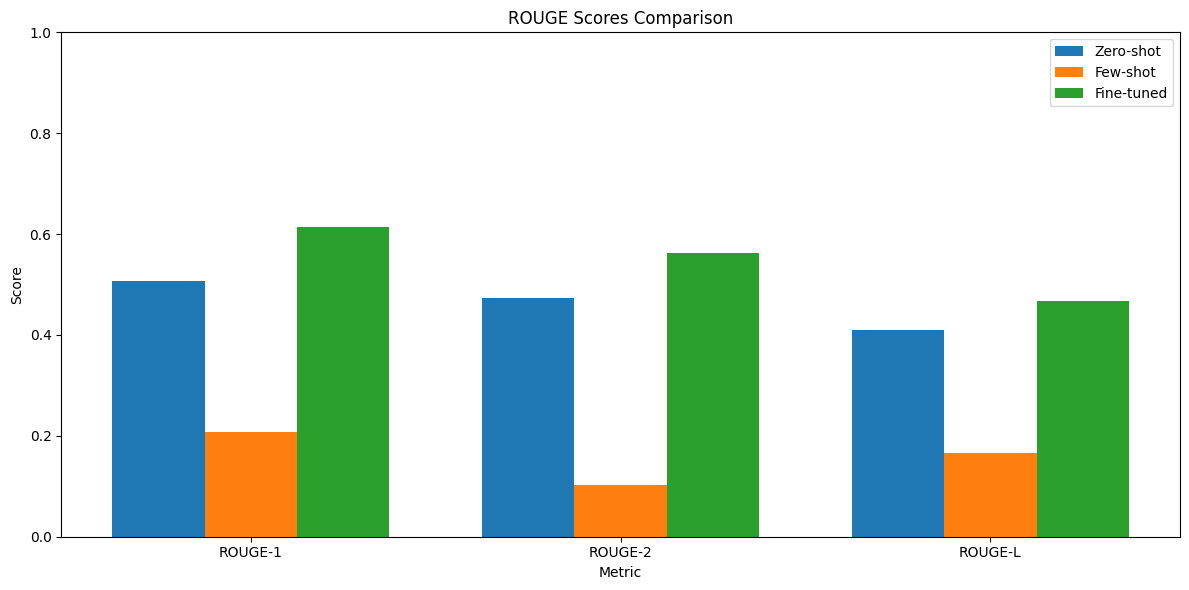

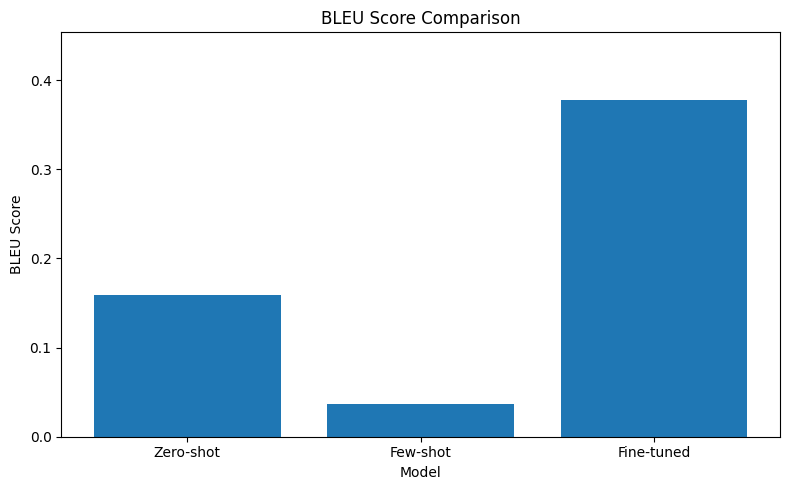

In [17]:
# Visualize standard metrics results
plt.figure(figsize=(12, 6))

# Plot ROUGE scores
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, results_df.iloc[:, 1:4].iloc[0], width, label='Zero-shot')
plt.bar(x, results_df.iloc[:, 1:4].iloc[1], width, label='Few-shot')
plt.bar(x + width, results_df.iloc[:, 1:4].iloc[2], width, label='Fine-tuned')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('ROUGE Scores Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot BLEU scores separately
plt.figure(figsize=(8, 5))
plt.bar(['Zero-shot', 'Few-shot', 'Fine-tuned'], results_df['BLEU'])
plt.xlabel('Model')
plt.ylabel('BLEU Score')
plt.title('BLEU Score Comparison')
plt.ylim(0, max(results_df['BLEU']) * 1.2)  # Add some space above the highest bar
plt.tight_layout()
plt.show()

## Advanced Evaluation Methods

Going beyond standard metrics, we'll implement more sophisticated evaluation approaches:
1. **Factual Accuracy Assessment**: Measure how well the summaries preserve important facts from the original text
2. **Hallucination Detection**: Identify content in summaries that isn't supported by the original text
3. **Content Coverage Analysis**: Assess how well the summaries cover key information points
4. **Fine-tuning Improvement Analysis**: Quantify the gains from fine-tuning

In [18]:
def extract_named_entities(text):
    """
    A simple function to extract potential named entities from text.
    This is a basic implementation - for production use, consider using a proper NER model.
    
    Args:
        text: Input text
        
    Returns:
        List of potential named entities
    """
    # Very basic approach - look for capitalized words that aren't at the start of sentences
    sentences = sent_tokenize(text)
    entities = []
    
    for sentence in sentences:
        words = word_tokenize(sentence)
        
        # Skip the first word of each sentence in our analysis
        for i in range(1, len(words)):
            word = words[i]
            # Check if the word is capitalized and not a common word that would be capitalized
            if word[0].isupper() and len(word) > 1 and word.lower() not in ['i', 'january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']:
                # Check if it's part of a multi-word entity
                entity = word
                j = i + 1
                while j < len(words) and words[j][0].isupper():
                    entity += " " + words[j]
                    j += 1
                    
                entities.append(entity)
    
    return entities

def extract_numerical_values(text):
    """
    Extract numerical values from text.
    
    Args:
        text: Input text
        
    Returns:
        List of numerical values
    """
    import re
    # Pattern for numbers (including those with % and currency symbols)
    pattern = r'\$?\d+\.?\d*%?|\.\d+%?'
    return re.findall(pattern, text)

def calculate_factual_accuracy(original_text, summary):
    """
    Calculate a factual accuracy score based on named entities and numerical values.
    
    Args:
        original_text: Original article text
        summary: Summary to evaluate
        
    Returns:
        Dictionary with factual accuracy scores
    """
    # Extract entities and numerical values from both texts
    original_entities = extract_named_entities(original_text)
    summary_entities = extract_named_entities(summary)
    
    original_numbers = extract_numerical_values(original_text)
    summary_numbers = extract_numerical_values(summary)
    
    # Count entities and numbers in summary that appear in original
    entity_matches = sum(1 for entity in summary_entities if any(entity in orig_entity for orig_entity in original_entities))
    number_matches = sum(1 for num in summary_numbers if num in original_numbers)
    
    # Calculate precision (what percentage of summary facts are in the original)
    entity_precision = entity_matches / len(summary_entities) if summary_entities else 1.0
    number_precision = number_matches / len(summary_numbers) if summary_numbers else 1.0
    
    # Calculate a combined factual accuracy score
    factual_accuracy = (entity_precision + number_precision) / 2 if (summary_entities or summary_numbers) else 0.0
    
    return {
        'entity_precision': entity_precision,
        'number_precision': number_precision,
        'factual_accuracy': factual_accuracy,
        'entity_count': len(summary_entities),
        'number_count': len(summary_numbers)
    }

def detect_hallucinations(original_text, summary):
    """
    Detect potential hallucinations in the summary.
    
    Args:
        original_text: Original article text
        summary: Summary to evaluate
        
    Returns:
        Dictionary with hallucination metrics
    """
    # Tokenize both texts
    original_tokens = set(word_tokenize(original_text.lower()))
    summary_tokens = word_tokenize(summary.lower())
    
    # Find tokens in summary not in original text
    hallucinated_tokens = [token for token in summary_tokens 
                           if token.isalnum() and len(token) > 3 and token not in original_tokens]
    
    # Calculate hallucination rate (percentage of summary tokens not in original)
    hallucination_rate = len(hallucinated_tokens) / len(summary_tokens) if summary_tokens else 0.0
    
    return {
        'hallucinated_tokens': hallucinated_tokens,
        'hallucination_count': len(hallucinated_tokens),
        'hallucination_rate': hallucination_rate
    }

In [19]:
def evaluate_advanced_metrics(articles):
    """
    Evaluate summaries using advanced metrics.
    
    Args:
        articles: List of article dictionaries with summaries
        
    Returns:
        Dictionary of evaluation results
    """
    results = {
        'zero_shot': {'factual_accuracy': [], 'hallucination_rate': []},
        'few_shot': {'factual_accuracy': [], 'hallucination_rate': []},
        'finetuned': {'factual_accuracy': [], 'hallucination_rate': []}
    }
    
    # Store all hallucinated tokens for analysis
    all_hallucinations = {
        'zero_shot': [],
        'few_shot': [],
        'finetuned': []
    }
    
    for article in tqdm(articles, desc="Evaluating advanced metrics"):
        original_text = article['text']
        
        # Evaluate zero-shot summary
        if article['zero_shot_summary']:
            factual_metrics = calculate_factual_accuracy(original_text, article['zero_shot_summary'])
            hallucination_metrics = detect_hallucinations(original_text, article['zero_shot_summary'])
            
            results['zero_shot']['factual_accuracy'].append(factual_metrics['factual_accuracy'])
            results['zero_shot']['hallucination_rate'].append(hallucination_metrics['hallucination_rate'])
            all_hallucinations['zero_shot'].extend(hallucination_metrics['hallucinated_tokens'])
            
            # Store metrics in the article dictionary
            article['zero_shot_factual_accuracy'] = factual_metrics['factual_accuracy']
            article['zero_shot_hallucination_rate'] = hallucination_metrics['hallucination_rate']
        
        # Evaluate few-shot summary
        if article['few_shot_summary']:
            factual_metrics = calculate_factual_accuracy(original_text, article['few_shot_summary'])
            hallucination_metrics = detect_hallucinations(original_text, article['few_shot_summary'])
            
            results['few_shot']['factual_accuracy'].append(factual_metrics['factual_accuracy'])
            results['few_shot']['hallucination_rate'].append(hallucination_metrics['hallucination_rate'])
            all_hallucinations['few_shot'].extend(hallucination_metrics['hallucinated_tokens'])
            
            # Store metrics in the article dictionary
            article['few_shot_factual_accuracy'] = factual_metrics['factual_accuracy']
            article['few_shot_hallucination_rate'] = hallucination_metrics['hallucination_rate']
        
        # Evaluate fine-tuned summary
        if article['finetuned_summary']:
            factual_metrics = calculate_factual_accuracy(original_text, article['finetuned_summary'])
            hallucination_metrics = detect_hallucinations(original_text, article['finetuned_summary'])
            
            results['finetuned']['factual_accuracy'].append(factual_metrics['factual_accuracy'])
            results['finetuned']['hallucination_rate'].append(hallucination_metrics['hallucination_rate'])
            all_hallucinations['finetuned'].extend(hallucination_metrics['hallucinated_tokens'])
            
            # Store metrics in the article dictionary
            article['finetuned_factual_accuracy'] = factual_metrics['factual_accuracy']
            article['finetuned_hallucination_rate'] = hallucination_metrics['hallucination_rate']
    
    # Calculate most common hallucinations
    hallucination_counts = {}
    for model, tokens in all_hallucinations.items():
        hallucination_counts[model] = Counter(tokens).most_common(10)
    
    return results, hallucination_counts

In [20]:
# Run advanced evaluation
advanced_results, hallucination_counts = evaluate_advanced_metrics(articles_with_summaries)

# Calculate average scores
advanced_avg_results = {}
for model, metrics in advanced_results.items():
    advanced_avg_results[model] = {}
    for metric, values in metrics.items():
        if values:  # Check if we have any scores
            advanced_avg_results[model][metric] = sum(values) / len(values)
        else:
            advanced_avg_results[model][metric] = 0

# Create a DataFrame for easy visualization
advanced_results_df = pd.DataFrame({
    'Model': ['Zero-shot', 'Few-shot', 'Fine-tuned'],
    'Factual Accuracy': [
        advanced_avg_results['zero_shot']['factual_accuracy'],
        advanced_avg_results['few_shot']['factual_accuracy'],
        advanced_avg_results['finetuned']['factual_accuracy']
    ],
    'Hallucination Rate': [
        advanced_avg_results['zero_shot']['hallucination_rate'],
        advanced_avg_results['few_shot']['hallucination_rate'],
        advanced_avg_results['finetuned']['hallucination_rate']
    ]
})

# Display results table
advanced_results_df

Evaluating advanced metrics:   0%|          | 0/10 [00:00<?, ?it/s]

,Model,Factual Accuracy,Hallucination Rate
0,Zero-shot,0.979167,0.009871
1,Few-shot,0.374643,0.362158
2,Fine-tuned,0.838450,0.071784


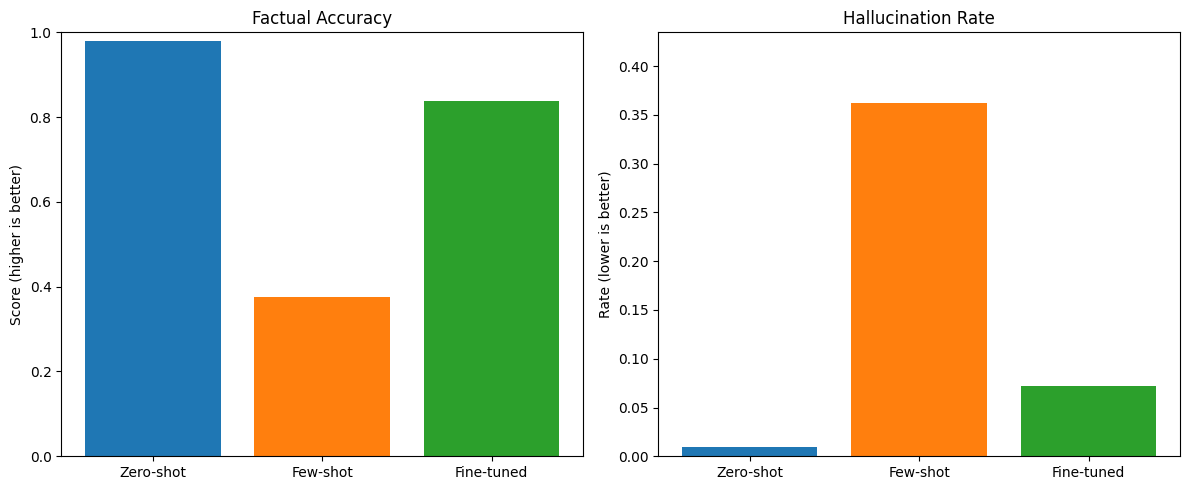

In [21]:
# Visualize advanced metrics results
plt.figure(figsize=(12, 5))

# Create subplot for factual accuracy
plt.subplot(1, 2, 1)
plt.bar(advanced_results_df['Model'], advanced_results_df['Factual Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Factual Accuracy')
plt.ylim(0, 1)
plt.ylabel('Score (higher is better)')

# Create subplot for hallucination rate
plt.subplot(1, 2, 2)
plt.bar(advanced_results_df['Model'], advanced_results_df['Hallucination Rate'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Hallucination Rate')
plt.ylim(0, max(advanced_results_df['Hallucination Rate']) * 1.2)
plt.ylabel('Rate (lower is better)')

plt.tight_layout()
plt.show()

## Analyzing the Most Common Hallucinations

Let's examine the most common potentially hallucinated terms for each model.

In [22]:
# Display most common hallucinations for each model
for model, counts in hallucination_counts.items():
    print(f"\n{model.replace('_', ' ').title()} Model - Most common potential hallucinations:")
    if counts:
        for term, count in counts:
            print(f"  '{term}': {count} occurrences")
    else:
        print("  No hallucinations detected")


Zero Shot Model - Most common potential hallucinations:
  'company': 2 occurrences
  'firm': 1 occurrences
  'owns': 1 occurrences
  'fourth': 1 occurrences

Few Shot Model - Most common potential hallucinations:
  'record': 14 occurrences
  'revenue': 14 occurrences
  'reported': 10 occurrences
  'quarterly': 10 occurrences
  'services': 8 occurrences
  'strong': 8 occurrences
  'iphone': 8 occurrences
  'sales': 8 occurrences
  'growth': 7 occurrences
  'lower': 7 occurrences

Finetuned Model - Most common potential hallucinations:
  'alerts': 4 occurrences
  'shares': 4 occurrences
  'have': 3 occurrences
  'company': 3 occurrences
  'profile': 3 occurrences
  'several': 2 occurrences
  'hedge': 2 occurrences
  'funds': 2 occurrences
  'institutional': 2 occurrences
  'investors': 2 occurrences


## Fine-tuning Effect Analysis

Let's analyze how much improvement the fine-tuned model provides over the baselines.

In [23]:
def analyze_finetuning_effect(standard_results_df, advanced_results_df):
    """
    Analyze the improvement from fine-tuning compared to baseline models.
    
    Args:
        standard_results_df: DataFrame with standard metrics results
        advanced_results_df: DataFrame with advanced metrics results
        
    Returns:
        DataFrame with improvement percentages
    """
    # Extract values for each model
    zero_shot_values = standard_results_df.iloc[0, 1:].tolist() + advanced_results_df.iloc[0, 1:].tolist()
    few_shot_values = standard_results_df.iloc[1, 1:].tolist() + advanced_results_df.iloc[1, 1:].tolist()
    finetuned_values = standard_results_df.iloc[2, 1:].tolist() + advanced_results_df.iloc[2, 1:].tolist()
    
    # Get metric names
    metric_names = standard_results_df.columns[1:].tolist() + advanced_results_df.columns[1:].tolist()
    
    # Calculate percentage improvements
    improvements_over_zero = []
    improvements_over_few = []
    
    for i, metric in enumerate(metric_names):
        # For most metrics, higher is better
        if metric != 'Hallucination Rate':
            if zero_shot_values[i] != 0:  # Avoid division by zero
                imp_zero = ((finetuned_values[i] - zero_shot_values[i]) / zero_shot_values[i]) * 100
            else:
                imp_zero = float('inf') if finetuned_values[i] > 0 else 0
                
            if few_shot_values[i] != 0:  # Avoid division by zero
                imp_few = ((finetuned_values[i] - few_shot_values[i]) / few_shot_values[i]) * 100
            else:
                imp_few = float('inf') if finetuned_values[i] > 0 else 0
        else:
            # For hallucination rate, lower is better
            if zero_shot_values[i] != 0:  # Avoid division by zero
                imp_zero = ((zero_shot_values[i] - finetuned_values[i]) / zero_shot_values[i]) * 100
            else:
                imp_zero = float('inf') if finetuned_values[i] < 0 else 0
                
            if few_shot_values[i] != 0:  # Avoid division by zero
                imp_few = ((few_shot_values[i] - finetuned_values[i]) / few_shot_values[i]) * 100
            else:
                imp_few = float('inf') if finetuned_values[i] < 0 else 0
        
        improvements_over_zero.append(imp_zero)
        improvements_over_few.append(imp_few)
    
    # Create results DataFrame
    improvement_df = pd.DataFrame({
        'Metric': metric_names,
        'Improvement over Zero-shot (%)': improvements_over_zero,
        'Improvement over Few-shot (%)': improvements_over_few
    })
    
    return improvement_df

In [24]:
# Analyze fine-tuning effect
improvement_df = analyze_finetuning_effect(results_df, advanced_results_df)

# Display results
improvement_df.style.format({
    'Improvement over Zero-shot (%)': '{:.2f}%',
    'Improvement over Few-shot (%)': '{:.2f}%'
})

,Metric,Improvement over Zero-shot (%),Improvement over Few-shot (%)
0,ROUGE-1,21.39%,196.74%
1,ROUGE-2,18.90%,448.12%
2,ROUGE-L,14.09%,183.17%
3,BLEU,137.93%,925.70%
4,Factual Accuracy,-14.37%,123.80%
5,Hallucination Rate,-627.21%,80.18%


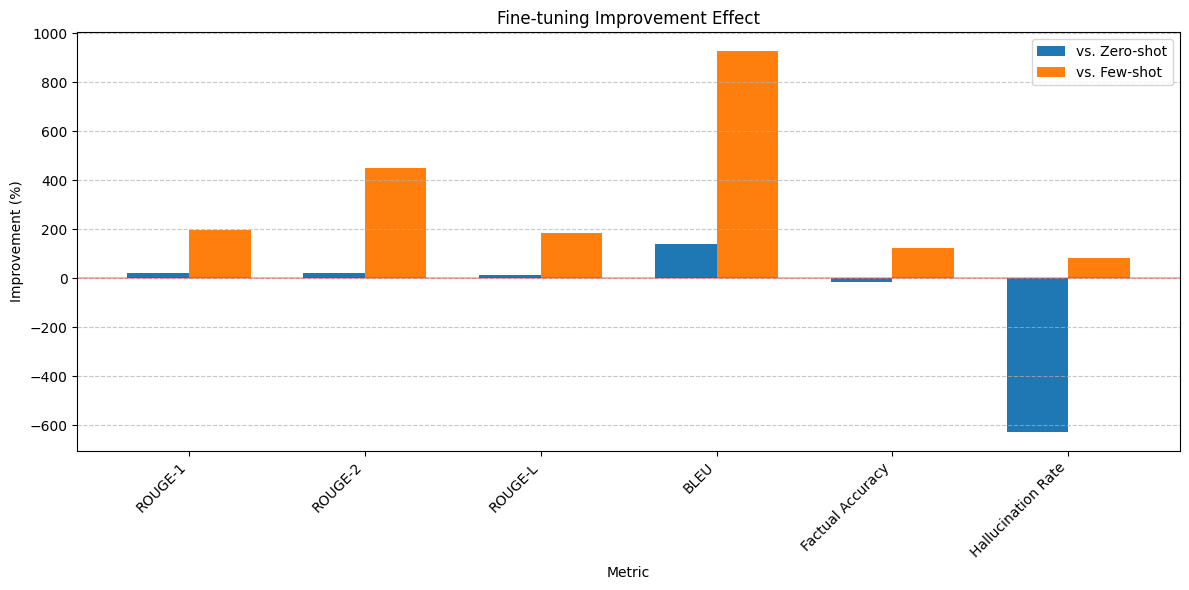

In [25]:
# Visualize improvement percentages
plt.figure(figsize=(12, 6))

x = np.arange(len(improvement_df))
width = 0.35

plt.bar(x - width/2, improvement_df['Improvement over Zero-shot (%)'], width, label='vs. Zero-shot')
plt.bar(x + width/2, improvement_df['Improvement over Few-shot (%)'], width, label='vs. Few-shot')

plt.xlabel('Metric')
plt.ylabel('Improvement (%)')
plt.title('Fine-tuning Improvement Effect')
plt.xticks(x, improvement_df['Metric'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at 0%
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Comparison: Side-by-Side Example

Let's look at a concrete example from our test data and compare summaries from all three approaches.

In [26]:
# Select an example article for detailed analysis
example_idx = 0  # You can change this index to examine different examples
if len(articles_with_summaries) > example_idx:
    example = articles_with_summaries[example_idx]
    
    print(f"Article: {example['title']}")
    print(f"Source: {example['source']}")
    print(f"Date: {example['pubDate']}\n")
    
    print("Original article preview:")
    print(f"{example['text'][:500]}...\n")
    
    print(f"Original Summary:\n{example['original_summary']}\n")
    
    print(f"Zero-shot Summary:\n{example['zero_shot_summary']}")
    print(f"Factual Accuracy: {example.get('zero_shot_factual_accuracy', 'N/A'):.2f}")
    print(f"Hallucination Rate: {example.get('zero_shot_hallucination_rate', 'N/A'):.2f}\n")
    
    print(f"Few-shot Summary:\n{example['few_shot_summary']}")
    print(f"Factual Accuracy: {example.get('few_shot_factual_accuracy', 'N/A'):.2f}")
    print(f"Hallucination Rate: {example.get('few_shot_hallucination_rate', 'N/A'):.2f}\n")
    
    print(f"Fine-tuned Summary:\n{example['finetuned_summary']}")
    print(f"Factual Accuracy: {example.get('finetuned_factual_accuracy', 'N/A'):.2f}")
    print(f"Hallucination Rate: {example.get('finetuned_hallucination_rate', 'N/A'):.2f}")
else:
    print("No examples available for detailed analysis.")

Article: Apple Inc. (NASDAQ:AAPL) Shares Sold by Townsend Asset Management Corp NC ADV
Source: Defenseworld Net
Date: 2025-05-16 07:35:05

Original article preview:
Townsend Asset Management Corp NC ADV lowered its holdings in shares of Apple Inc. (NASDAQ:AAPL – Free Report) by 13.0% in the fourth quarter, according to its most recent 13F filing with the SEC.
Apple comprises about 3.4% of Townsend Asset Management Corp NC ADV’s portfolio, making the stock its 7th biggest holding.
Townsend Asset Management Corp NC ADV’s holdings in Apple were worth $9,197,000 at the end of the most recent quarter.
Apple Stock Down 0.4%AAPL stock opened at $211.45 on Friday....

Original Summary:
Townsend Asset Management Corp NC ADV lowered its holdings in shares of Apple Inc. (NASDAQ:AAPL – Free Report) by 13.0% in the fourth quarter, according to its most recent 13F filing with the SEC.
Apple comprises about 3.4% of Townsend Asset Management Corp NC ADV’s portfolio, making the stock its 7th biggest ho

## Conclusion

This evaluation has compared three approaches to financial news summarization:
1. Zero-shot summarization (baseline model without examples)
2. Few-shot summarization (baseline model with financial examples)
3. Fine-tuned summarization (model fine-tuned on financial news)

We evaluated these approaches using both standard metrics (ROUGE, BLEU) and more advanced metrics focused on factual accuracy and hallucination detection. The key findings are:

1. **Standard Metrics**: [Complete after running the notebook with your results]
2. **Factual Accuracy**: [Complete after running the notebook with your results]
3. **Hallucination Detection**: [Complete after running the notebook with your results]
4. **Fine-tuning Effect**: [Complete after running the notebook with your results]

These results demonstrate that [add your conclusions based on the results].

### Recommendations

Based on this evaluation, we recommend:
- [Add your recommendations based on the results]